In [1]:
import pandas as pd

# Load the uploaded dataset
# file_path = "/Car_sales.csv"
car_sales = pd.read_csv("Car_sales.csv")

# Show the first few rows to understand the structure
car_sales.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [2]:
import matplotlib.pyplot as plt
import plotly.express as px

# Clean data: drop rows with missing sales values
car_sales_clean = car_sales.dropna(subset=['Sales_in_thousands'])

In [4]:
car_sales_clean.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [5]:
# Aggregate sales by Model (in case of duplicates)
sales_by_model = car_sales_clean.groupby('Model')['Sales_in_thousands'].sum().sort_values(ascending=False)

sales_by_model.head()

Model
F-Series    540.561
Explorer    276.747
Camry       247.994
Taurus      245.815
Accord      230.902
Name: Sales_in_thousands, dtype: float64

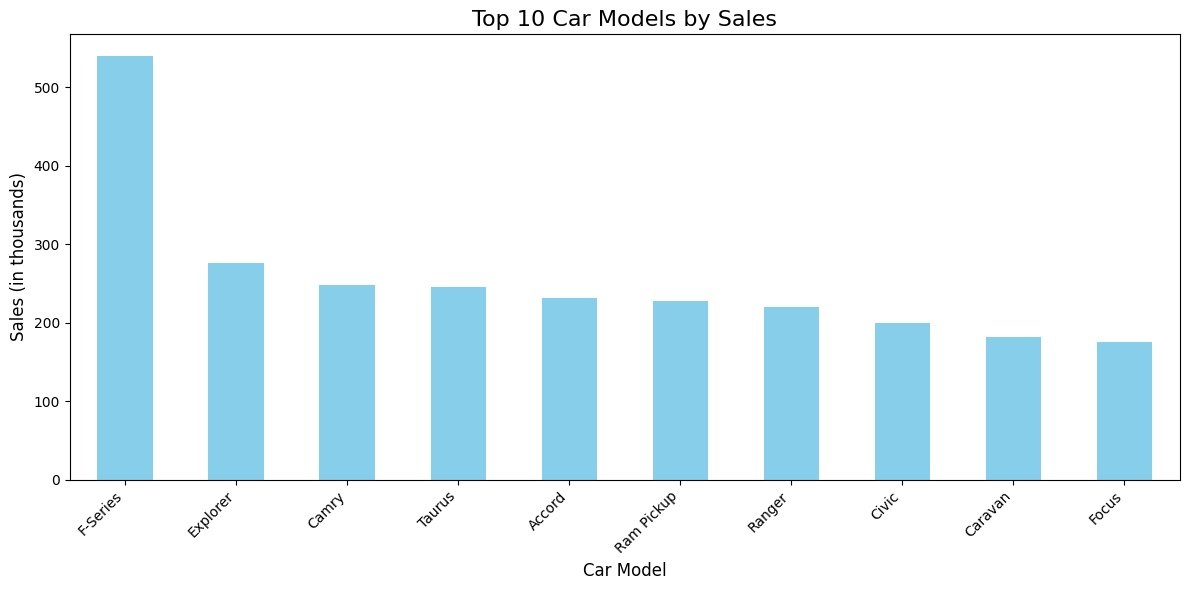

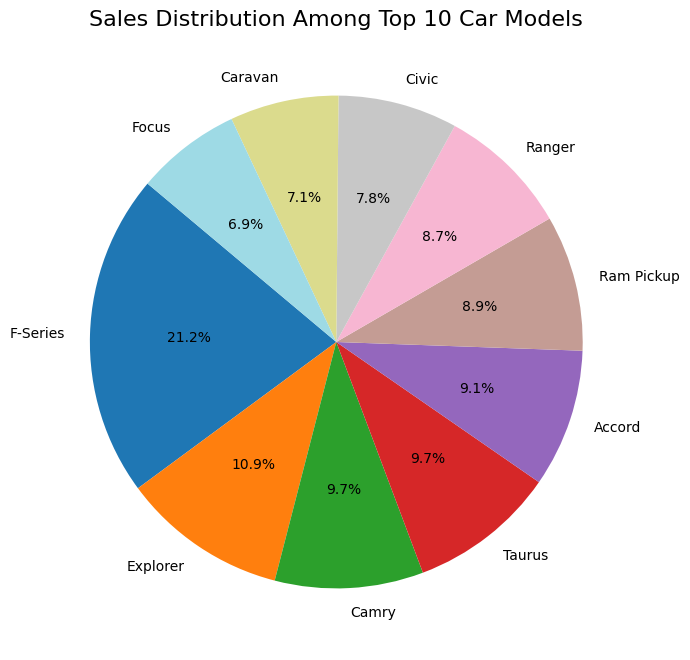

In [6]:
# ---------------- MATPLOTLIB VISUALS ----------------

# Bar Chart (Top 10 Models)
plt.figure(figsize=(12,6))
sales_by_model.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Car Models by Sales", fontsize=16)
plt.xlabel("Car Model", fontsize=12)
plt.ylabel("Sales (in thousands)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pie Chart (Top 10 Models)
plt.figure(figsize=(8,8))
sales_by_model.head(10).plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='tab20')
plt.title("Sales Distribution Among Top 10 Car Models", fontsize=16)
plt.ylabel("")  # Remove y-label for neatness
plt.show()

# ---------------- PLOTLY INTERACTIVE VISUALS ----------------

# Interactive Bar Chart
fig_bar = px.bar(
    sales_by_model.head(10).reset_index(),
    x="Model", y="Sales_in_thousands",
    title="Top 10 Car Models by Sales (Interactive)",
    labels={"Sales_in_thousands":"Sales (in thousands)", "Model":"Car Model"},
    color="Sales_in_thousands",
    color_continuous_scale="Blues"
)
fig_bar.show()

# Interactive Pie Chart
fig_pie = px.pie(
    sales_by_model.head(10).reset_index(),
    names="Model", values="Sales_in_thousands",
    title="Sales Distribution Among Top 10 Car Models (Interactive)",
    hole=0.3
)
fig_pie.show()